In [5]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split FIRST before the scaler ever sees the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit scaler ONLY on training data, then apply to test separately
# This prevents test set statistics from leaking into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_train_t = torch.LongTensor(y_train.values)
y_test_t  = torch.LongTensor(y_test.values)

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.layers(x)

input_size = X_train_t.shape[1]
num_classes = len(y.unique())
model = NeuralNet(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=512, shuffle=True)

for epoch in range(10):
    model.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/10 Loss: {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).argmax(dim=1).numpy()

    print(classification_report(y_test, y_pred))

Epoch 1/10 Loss: 0.0002
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25455
           1       1.00      1.00      1.00     31765

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220

Epoch 2/10 Loss: 0.0001
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25455
           1       1.00      1.00      1.00     31765

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220

Epoch 3/10 Loss: 0.0002
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25455
           1       1.00      1.00      1.00     31765

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
we

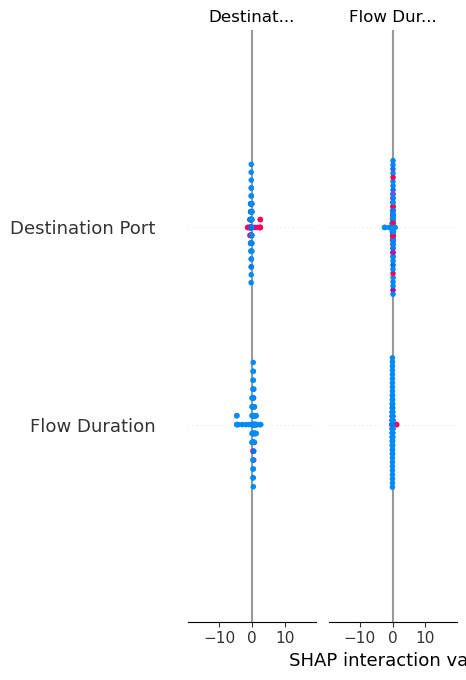

In [8]:
import matplotlib.pyplot as plt
import shap

model.to('cpu')
X_train_cpu = X_train_t[:100].to("cpu")
X_test_cpu  = X_test_t[:100].to('cpu')
explainer = shap.DeepExplainer(model, X_train_cpu)
shap_values = explainer.shap_values(X_test_cpu)
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=X.columns, class_names=le.classes_, show=False)
plt.tight_layout()
plt.show()